# 1.4 — Composing Functions, at the computer

Do the **pen-and-paper worksheet first**. Here you bolt machines together, watch a machine eat
its own output — and at the end, a glimpse of something genuinely strange.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt
from plots import plot_functions, axes_through_origin

f(g(1)) = 16    <- g first: 1 -> 4 -> 16
g(f(1)) = 4     <- f first: 1 -> 1 -> 4


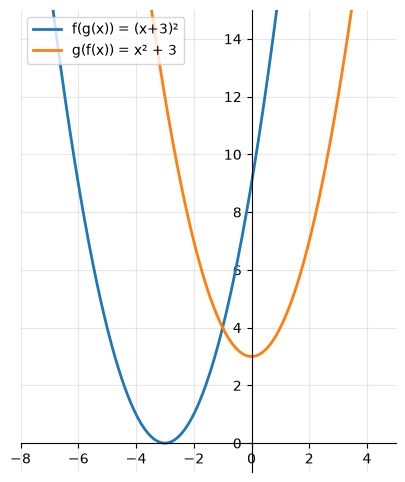

In [2]:
# Order matters — the worksheet's Part A, as running code:

def f(x): return x ** 2
def g(x): return x + 3

print("f(g(1)) =", f(g(1)), "   <- g first: 1 -> 4 -> 16")
print("g(f(1)) =", g(f(1)), "    <- f first: 1 -> 1 -> 4")

# And the two combined blueprints are two different curves:
plot_functions({
    "f(g(x)) = (x+3)²": lambda x: f(g(x)),
    "g(f(x)) = x² + 3": lambda x: g(f(x)),
}, xlim=(-8, 5), ylim=(-1, 15))
plt.show()

# Same two machines, opposite plumbing: one valley sits at x = -3, the other floats at y = 3.
# (Which is which? Unit 1.3 tells you before the legend does.)

In [3]:
# YOUR TURN — worksheet problem 8 built the three-layer pipeline c(b(a(x))):
#   a(x) = x + 1,  b(x) = 2x,  c(x) = x²
# You expanded the blueprint on paper. Now let Python vouch for it.

def a(x): return x + 1
def b(x): return 2 * x
def c(x): return x ** 2

def pipeline(x):
    return c(b(a(x)))          # a deep network in miniature: layer, layer, layer

def my_blueprint(x):
    return 0    # <- replace 0 with your expanded Part B formula

xs = np.linspace(-10, 10, 100)
print("blueprint matches pipeline:", np.all(pipeline(xs) == my_blueprint(xs)))

blueprint matches pipeline: False


## 1. Machines that eat their own output

The worksheet's deep-end: $f(x) = \frac{x}{2} + 1$, fed to itself. You computed five steps by
hand and solved for the fixed point. Watch the whole approach:

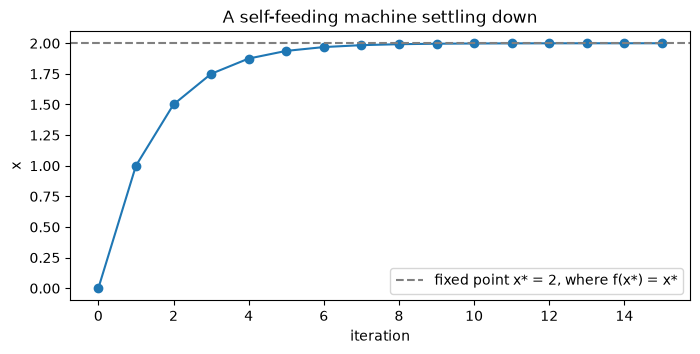

In [4]:
f_half = lambda x: x / 2 + 1

x = 0.0
trajectory = [x]                    # a list — we'll append each step onto it
for step in range(15):
    x = f_half(x)                   # output becomes the next input
    trajectory.append(x)

plt.figure(figsize=(8, 3.5))
plt.plot(trajectory, "o-")
plt.axhline(2, color="gray", linestyle="--", label="fixed point x* = 2, where f(x*) = x*")
plt.xlabel("iteration"); plt.ylabel("x")
plt.title("A self-feeding machine settling down")
plt.legend()
plt.show()

# It creeps to 2 and stays: f(2) = 2, so once there, nothing changes. Calm, obedient, predictable.
# Hold that thought.

## 2. 🌀 Now change almost nothing

Take another innocent machine — a plain quadratic from the zoo: $f(x) = 3.9\,x\,(1 - x)$.
Same game: feed it to itself. It's ONE composition, iterated, exactly like the cell above.

Surely it also settles down?

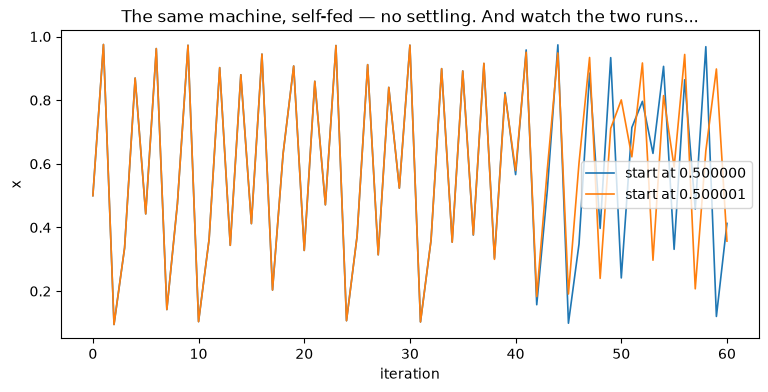

In [5]:
logistic = lambda x: 3.9 * x * (1 - x)

def iterate(f, x0, n):
    """Feed machine f its own output n times, recording every value."""
    xs = [x0]
    for _ in range(n):              # _ means 'loop variable we don't need'
        xs.append(f(xs[-1]))        # xs[-1] = the most recent value
    return xs

run1 = iterate(logistic, 0.500000, 60)
run2 = iterate(logistic, 0.500001, 60)     # starting point differs by ONE MILLIONTH

plt.figure(figsize=(9, 4))
plt.plot(run1, linewidth=1.2, label="start at 0.500000")
plt.plot(run2, linewidth=1.2, label="start at 0.500001")
plt.xlabel("iteration"); plt.ylabel("x")
plt.title("The same machine, self-fed — no settling. And watch the two runs...")
plt.legend()
plt.show()

No fixed point. No repeating cycle. And the two runs — identical machines, starting points
differing by a millionth — agree for a while, then **completely part ways**. This is **chaos**:
not randomness (every step was computed by one tidy quadratic), but a deterministic system so
sensitive that prediction dissolves. It's why weather forecasts die after ~10 days.

One innocent machine from the zoo. Composition with itself. That's ALL this is.

**After the boss worksheet, Interlude I.2 is your reward: you'll map every value of that 3.9 knob
and generate the bifurcation diagram — one of the most beautiful images in mathematics —
with your own code.**

## The deep-learning punchline

A 50-layer network is `f50(f49(...f2(f1(x))...))` — the same plumbing you built in this notebook.
And Module 3's chain rule will answer the training question: *wiggle the input of a pipeline,
how much does the output wiggle?* (Worksheet problem 15 was the whisper: effects multiply
down the chain.)

---
*Done? Photograph your worksheet into `scans/inbox/`.
Next: 1.5 — sigmoid & friends, and why deep networks NEED nonlinearity.*